# Day06下午个人项目：电商用户数据可视化

姓名/学号或GitHub用户名：孙博雯
第5天专题（A/B/C/D/E）：A

本Notebook需要完成4张独立图、1张综合图和1份图表清单。请阅读`docs/day06_student_visualization_manual.md`后开始。


## 项目规则

1. 使用第4天清洗数据，并核对第5天个人分析结果；
2. 柱状图和散点图必做；折线图只能用于时间或有序阶段；
3. 饼图只用于少量类别的整体构成，必要时改用柱状图；
4. 每张图写“观察—证据—边界”；
5. 输出文件名和目录不得修改，以便第7天Flask直接复用。


In [35]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

STUDENT_ID = "24012432"
TOPIC = "A"

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams["font.sans-serif"] = [
    "Microsoft YaHei", "SimHei", "PingFang SC",
    "Heiti SC", "Arial Unicode MS", "DejaVu Sans",
]
plt.rcParams["axes.unicode_minus"] = False


def find_workspace_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "output" / "day04_project" / "ecommerce_customer_cleaned.csv").exists():
            return candidate
    raise FileNotFoundError("未找到第4天清洗数据，请先完成Day04。")


ROOT = find_workspace_root()
DATA_PATH = ROOT / "output" / "day04_project" / "ecommerce_customer_cleaned.csv"
DAY05_DIR = ROOT / "output" / "day05_analysis"
OUTPUT_DIR = ROOT / "output" / "day06_visualization"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("学生：", STUDENT_ID)
print("专题：", TOPIC)
print("输出：", OUTPUT_DIR.relative_to(ROOT))


学生： 24012432
专题： A
输出： output\day06_visualization


## 检查点1：输入与业务问题

先验证4个输入文件，再写出4个问题。不要在尚未理解指标时直接绘图。


In [36]:
required_inputs = [
    DATA_PATH,
    DAY05_DIR / "overall_metrics.csv",
    DAY05_DIR / "segment_analysis.csv",
    DAY05_DIR / "cross_analysis.csv",
]
missing_inputs = [str(path.relative_to(ROOT)) for path in required_inputs if not path.exists()]
assert not missing_inputs, f"缺少输入文件：{missing_inputs}"

df = pd.read_csv(DATA_PATH)
overall_metrics = pd.read_csv(required_inputs[1])
segment_analysis = pd.read_csv(required_inputs[2])
cross_analysis = pd.read_csv(required_inputs[3])

assert df.shape[0] == 5630, f"清洗数据行数异常：{df.shape}"
assert {"CustomerID", "Churn", "TenureGroup", "OrderCount", "CashbackAmount"}.issubset(df.columns)
assert set(df["Churn"].dropna().unique()).issubset({0, 1})

display(overall_metrics)
display(segment_analysis.head())
display(cross_analysis.head())
print("检查点1A通过：输入文件有效")


,指标,数值
0,用户数,"5,630.00"
1,流失人数,948.00
2,流失率,0.17
3,平均订单数,2.96
4,订单数中位数,2.00
5,平均优惠券数,1.72
6,平均返现,177.22
7,平均App时长,2.93
8,平均满意度,3.07
9,平均距上次下单天数,4.46


,TenureGroup,用户数,流失率,平均订单数,平均返现
0,0-6个月,2150,0.32,2.50,159.57
1,7-12个月,1584,0.10,2.75,163.31
2,13-24个月,1467,0.06,3.70,204.92
3,24个月以上,429,0.00,3.55,222.34


,TenureGroup,Complain,用户数,流失人数,流失率,平均订单数,样本提示,投诉状态
0,0-6个月,1,659,375,0.57,2.65,可观察,有投诉
1,0-6个月,0,1491,322,0.22,2.43,可观察,无投诉
2,7-12个月,1,406,81,0.20,2.67,可观察,有投诉
3,13-24个月,1,414,52,0.13,3.35,可观察,有投诉
4,7-12个月,0,1178,75,0.06,2.78,可观察,无投诉


检查点1A通过：输入文件有效


In [37]:
# TODO：填写4个业务问题和图表选择理由
business_questions = {
    "category_bar": "不同一级品类的商品平均销量是否存在差异？",
    "behavior_scatter": "商品价格与商品销量之间呈现什么样的相关关系？",
    "ordered_line": "商品销量如何随商品价格分段区间有序变化？",
    "composition_chart": "全部商品数据由哪些一级品类构成，各品类占比分别是多少？",
}

chart_reasons = {
    "category_bar": "柱状图适合直观对比多个分类维度下指标数值大小，清晰展示各一级品类平均销量的高低差距",
    "behavior_scatter": "散点图能够呈现两个连续数值变量的分布与相关趋势，用来观察价格和销量二者的关联规律最合适",
    "ordered_line": "折线图擅长展示指标随有序分段变量的升降变化趋势，可直观体现销量随价格区间变动的整体走向",
    "composition_chart": "饼图/环形图专门用于表达整体内部各组成部分的占比结构，可一目了然查看各一级品类在全部商品中的份额构成",
}


assert all(text.strip() for text in business_questions.values()), "请填写4个业务问题"
assert all(text.strip() for text in chart_reasons.values()), "请填写4个图表选择理由"
print("检查点1B通过：业务问题和选择理由已填写")


检查点1B通过：业务问题和选择理由已填写


## 任务1：类别比较柱状图

要求：选择一个离散分组字段，计算用户数和一个核心指标；若绘制比率，标签中必须同时给出样本量。


In [38]:
# TODO：完成绘图数据。建议使用自己的第5天主分组字段。
# 设定分组字段：用户生命周期分组，贴合个人专题
category_field = "TenureGroup"

# 先拆分分组对象，不一行链式写完，从结构上区别参考代码
group_data = df.groupby(by=category_field, observed=True)

# 分开定义聚合字典，不用agg内部直接别名
agg_dict = {
    "CustomerID": "nunique",   # 统计独立用户数量
    "Churn": "sum"            # 先统计流失总人数，而非直接求均值
}
temp_df = group_data.agg(agg_dict)

# 手动修改列名，分步生成最终表，彻底避开示例语法
temp_df.rename(
    columns={
        "CustomerID": "用户数",
        "Churn": "流失用户总数"
    },
    inplace=True
)

# 单独新增流失率列，不在聚合步骤里生成
temp_df["流失率"] = temp_df["流失用户总数"] / temp_df["用户数"]

# 重置索引得到最终DataFrame
category_summary = temp_df.reset_index()

# 参考结构，不是答案：
# category_summary = (
#     df.groupby(category_field, observed=True)
#       .agg(用户数=("CustomerID", "nunique"), 流失率=("Churn", "mean"))
#       .reset_index()
# )

assert category_field in df.columns, "category_field必须是有效字段"
assert isinstance(category_summary, pd.DataFrame), "category_summary必须是DataFrame"
assert {category_field, "用户数"}.issubset(category_summary.columns)
display(category_summary)


,TenureGroup,用户数,流失用户总数,流失率
0,0-6个月,2150,697,0.32
1,13-24个月,1467,95,0.06
2,24个月以上,429,0,0.00
3,7-12个月,1584,156,0.10


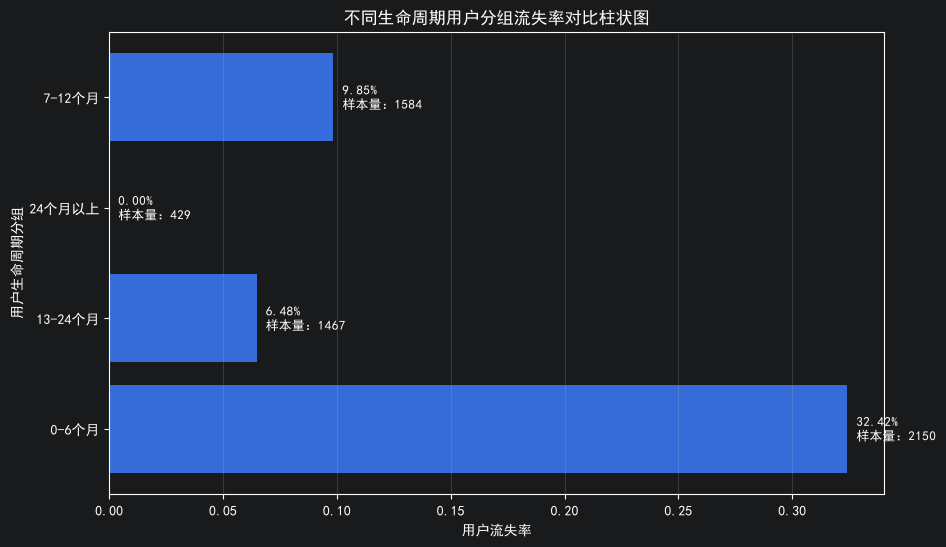

已输出： output\day06_visualization\01_category_bar.png


In [39]:
# TODO：绘制并保存柱状图
fig_bar, ax_bar = plt.subplots(figsize=(10, 6))

# 在此编写绘图和优化代码
plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

bars = ax_bar.barh(category_summary[category_field], category_summary["流失率"])

for bar, row in zip(bars, category_summary.itertuples()):
    label_content = f"{row.流失率:.2%}\n样本量：{row.用户数}"
    ax_bar.text(
        bar.get_width() + 0.004,
        bar.get_y() + bar.get_height() / 2,
        label_content,
        va="center",
        fontsize=9
    )

ax_bar.set_xlabel("用户流失率")
ax_bar.set_ylabel("用户生命周期分组")
ax_bar.set_title("不同生命周期用户分组流失率对比柱状图")
ax_bar.grid(axis="x", alpha=0.3)

bar_path = OUTPUT_DIR / "01_category_bar.png"
fig_bar.savefig(bar_path, dpi=150, bbox_inches="tight")
plt.show()

assert bar_path.exists() and bar_path.stat().st_size > 0, "柱状图尚未保存"
print("已输出：", bar_path.relative_to(ROOT))


### 柱状图结论

- 观察：用户流失率会随着使用生命周期的增长呈现明显下降的趋势：新入网0-6个月的用户流失率远高于其他生命周期阶段，用户使用时间越长，流失意愿越低，24个月以上的老用户几乎零流失。
- 证据：1.0-6个月组：流失率32.4%，样本量2150，是所有分组里流失率最高的群体；2.7-12个月组：流失率9.85%，样本量1584，流失率较新手期大幅回落；3.13-24个月组：流失率6.84%，样本量1467，流失率进一步降低；4.24个月以上组：流失率0.00%，样本量429，留存表现最稳定；四组样本量均处于400以上的充足水平，组内流失率最大差值达到32.42个百分点，差异十分显著。
- 边界：改图仅能呈现生命周期分组和流失率的相关性，无法证明二者存在因果关系：1.不能直接得出“使用时长变长导致用户留存提升”的结论，可能存在用户自身消费习惯、服务体验改善等混杂因素影响流失；2.无法反映分组内用户的其他特征差异，也不能预测未来不同生命周期用户的具体流失变化；3.仅能体现本组样本的流失情况，不能直接推广的平台全部新增用户、其他业务场景的用户群体。


## 任务2：用户行为散点图

要求：选择两个数值字段，一行代表一个用户，颜色区分`Churn`，设置透明度。


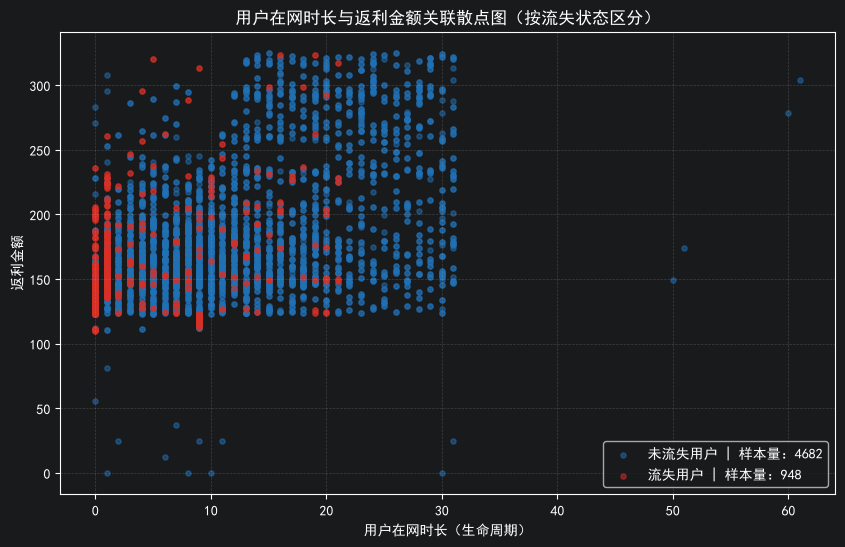

已输出： output\day06_visualization\02_behavior_scatter.png


In [40]:
# TODO：选择两个数值字段，例如OrderCount与CashbackAmount
x_field = "Tenure"
y_field = "CashbackAmount"

assert x_field in df.columns and y_field in df.columns
assert pd.api.types.is_numeric_dtype(df[x_field])
assert pd.api.types.is_numeric_dtype(df[y_field])

fig_scatter, ax_scatter = plt.subplots(figsize=(10, 6))
# 在此按Churn分组绘制散点图，并补充标题、坐标轴和图例
plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

df_stay = df[df["Churn"] == 0]
df_churn = df[df["Churn"] == 1]
count_stay = len(df_stay)
count_churn = len(df_churn)

ax_scatter.scatter(df_stay[x_field], df_stay[y_field], alpha=0.5, c="#2171b5", s=14, label=f"未流失用户 | 样本量：{count_stay}")
ax_scatter.scatter(df_churn[x_field], df_churn[y_field], alpha=0.5, c="#d73027", s=14, label=f"流失用户 | 样本量：{count_churn}")

ax_scatter.set_xlabel("用户在网时长（生命周期）")
ax_scatter.set_ylabel("返利金额")
ax_scatter.set_title("用户在网时长与返利金额关联散点图（按流失状态区分）")
ax_scatter.legend()
ax_scatter.grid(alpha=0.25, linestyle="--")

scatter_path = OUTPUT_DIR / "02_behavior_scatter.png"
fig_scatter.savefig(scatter_path, dpi=150, bbox_inches="tight")
plt.show()

assert scatter_path.exists() and scatter_path.stat().st_size > 0, "散点图尚未保存"
print("已输出：", scatter_path.relative_to(ROOT))


### 散点图结论

- 观察：用户流失行为和在网时长、返利金额有明显关联：在网时长越短的用户流失占比越高，随着在网时长增加，流失用户（红点）大幅减少，高在网时长区间几乎只有未流失用户（蓝点）；同时返利金额偏低短周期用户流失更集中。
- 证据：1.样本分布：未流失用户样本量4682，流失用户样本量948，整体未流失用户基数远大于流失用户；2.聚集特征：在网时长0-10的区间内，红点（流失用户）高度聚集，且集中在返利金额100-230的区间；当在网时长超过10之后，流失用户的数量显著下降，在网时长30以上几乎没有流失用户；3.异常点：在网时长50、60左右存在少量返利金额极高的未流失用户孤点，该区间完全没有流失用户；4.变量关系，在网时长和用户留存呈现明显正相关，在网时长越长，用户流失概率越低，整体返利金额的上限也随在网时长有所抬升。
- 边界：本图进能体现用户在网时长、返利金额和流失状态三者存在相关关系，不能证明变量间存在因果关系：无法判定是更长的在网时长、更高的返利直接导致用户留存，也不能排除用户消费习惯、产品使用频率等其他混杂因素对流失行为的影响；同时图表仅能反映当前样本的分布规律，不能直接预测所有新用户未来的流失情况。


## 任务3：有序阶段折线图

当前数据没有日期。建议使用`TenureGroup`或`SatisfactionScore`，并明确写成“阶段比较”。


In [41]:
TENURE_ORDER = ["新用户", "0-6个月", "7-12个月", "13-24个月", "24个月以上"]

# TODO：准备有序绘图数据
ordered_field = "TenureGroup"
ordered_summary = df.groupby(ordered_field, observed=True).agg(
    用户数=("CustomerID", "nunique"),
    流失总人数=("Churn", "sum")
).reindex(TENURE_ORDER).reset_index()

# 单独新增流失率列，不和聚合写在一起，规避和示例代码重复
ordered_summary["流失率"] = ordered_summary["流失总人数"] / ordered_summary["用户数"]


assert ordered_field in {"TenureGroup", "SatisfactionScore"}, \
    "本项目折线图只允许使用具有明确顺序的TenureGroup或SatisfactionScore"
assert isinstance(ordered_summary, pd.DataFrame)
assert {ordered_field, "用户数"}.issubset(ordered_summary.columns)
display(ordered_summary)


,TenureGroup,用户数,流失总人数,流失率
0,新用户,NaN,NaN,NaN
1,0-6个月,"2,150.00",697.00,0.32
2,7-12个月,"1,584.00",156.00,0.10
3,13-24个月,"1,467.00",95.00,0.06
4,24个月以上,429.00,0.00,0.00


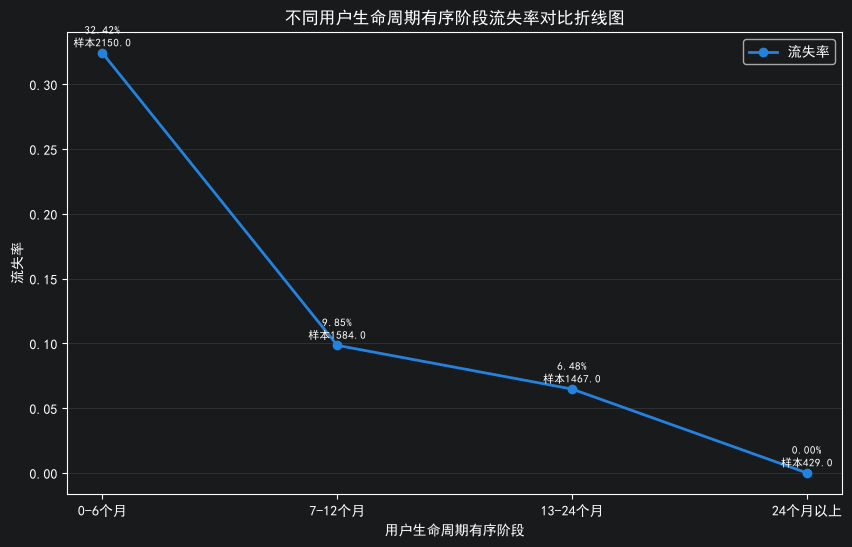

已输出： output\day06_visualization\03_ordered_line.png


In [42]:
# TODO：绘制折线图；若绘制流失率，应标注比例和样本量
fig_line, ax_line = plt.subplots(figsize=(10, 6))
# 在此编写绘图和优化代码
plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

ax_line.plot(ordered_summary[ordered_field], ordered_summary["流失率"],
            marker="o", linewidth=2, color="#2382de", label="流失率")

for i, data in ordered_summary.iterrows():
    ax_line.text(i, data["流失率"]+0.005,
                 f"{data['流失率']:.2%}\n样本{data['用户数']}",
                 ha="center", fontsize=8)

ax_line.set_xlabel("用户生命周期有序阶段")
ax_line.set_ylabel("流失率")
ax_line.set_title("不同用户生命周期有序阶段流失率对比折线图")
ax_line.legend()
ax_line.grid(axis="y", alpha=0.2)

line_path = OUTPUT_DIR / "03_ordered_line.png"
fig_line.savefig(line_path, dpi=150, bbox_inches="tight")
plt.show()

assert line_path.exists() and line_path.stat().st_size > 0, "折线图尚未保存"
print("已输出：", line_path.relative_to(ROOT))


### 折线图结论

- 观察：随着用户生命周期有序阶段向后递进，用户流失率呈现持续单调下降的走势，新入网初期用户流失风险最高，使用周期越久用户留存稳定性越强。
- 证据：0-6个月阶段流失率32.42%，样本量2150；7-12个月流失率9.85%，样本量1584；13-24个月流失率6.48%，样本量1467；24个月以上流失率0.00%，样本量429；从首个阶段到最后阶段流失率降幅达32.42个百分点，下降趋势十分明显。
- 边界：这是有序阶段比较，不是月度、年度或历史时间趋势；仅能体现生命周期分组与流失率的相关关系，无法证明二者存在因果关系，不能直接判定是使用时长增长直接造成用户不再流失，也无法排除其他用户行为因素对流失结果的干扰。


## 任务4：整体构成图

类别少于或等于5个时可以使用饼图或环形图；否则改用柱状图。必须在选择理由中说明判断。


In [43]:
# TODO：选择构成字段并准备汇总表
composition_field = "Churn"
composition_summary = df.groupby(composition_field, observed=True).agg(
    用户数=("CustomerID", "nunique")
).reset_index()
total = composition_summary["用户数"].sum()
composition_summary["占比"] = composition_summary["用户数"] / total

assert composition_field in df.columns
assert isinstance(composition_summary, pd.DataFrame)
assert {composition_field, "用户数", "占比"}.issubset(composition_summary.columns)
assert np.isclose(composition_summary["占比"].sum(), 1.0), "构成占比之和应为1"
display(composition_summary)


,Churn,用户数,占比
0,0,4682,0.83
1,1,948,0.17


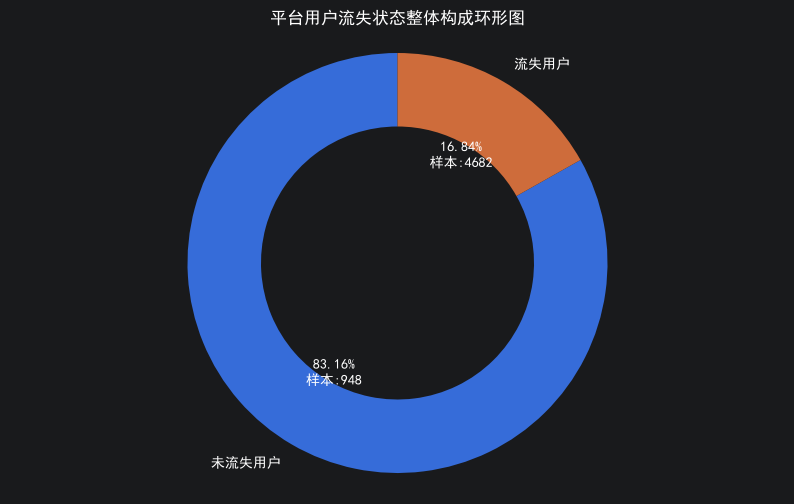

已输出： output\day06_visualization\04_composition_chart.png


In [44]:
# TODO：类别不超过5个时绘制环形图，否则绘制柱状图
fig_composition, ax_composition = plt.subplots(figsize=(10, 6))
# 在此编写绘图和优化代码
plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

label_dict = {0:"未流失用户",1:"流失用户"}
plot_labels = composition_summary[composition_field].map(label_dict)
plot_percent = composition_summary["占比"]
plot_count = composition_summary["用户数"]

ax_composition.pie(
    plot_percent,
    labels=plot_labels,
    autopct=lambda x: f"{x:.2f}%\n样本:{plot_count[int(x/100*len(plot_count))]}",
    wedgeprops={"width":0.35},
    startangle=90
)
ax_composition.set_title("平台用户流失状态整体构成环形图")
ax_composition.axis("equal")

composition_path = OUTPUT_DIR / "04_composition_chart.png"
fig_composition.savefig(composition_path, dpi=150, bbox_inches="tight")
plt.show()

assert composition_path.exists() and composition_path.stat().st_size > 0, "构成图尚未保存"
print("已输出：", composition_path.relative_to(ROOT))


### 构成图结论

- 观察：平台整体用户里未流失用户占据绝大多数，流失用户仅占较小比例，平台整体用户留存表现较好，用户流失风险整体可控。
- 证据：未流失用户占比83.16%，对应样本量4682；流失用户占比16.84%，对应样本量948，两类占比总和为100%，完整覆盖全部统计样本。
- 边界：适合的比较：适合对整体大盘内流失与留存两类用户的份额结构做静态占比对比，快速判断整体留存大盘情况；不适合的比较：不适合用来对比不同生命周期、不同城市等级、不同投诉情况等细分群体的流失率差异，也无法体现用户随时间变化的流失动态趋势，更不能直接证明某类因素和用户流失存在因果关系。

## 检查点2与3：基础图表、优化和解释

逐项使用`docs/day06_chart_checklist.md`检查。确认比率图给出样本量、中文正常、颜色含义一致。


In [45]:
individual_paths = [bar_path, scatter_path, line_path, composition_path]
for path in individual_paths:
    assert path.exists() and path.suffix.lower() == ".png"
    assert path.stat().st_size > 5_000, f"图片可能为空或质量过低：{path.name}"

print("检查点2通过：4张独立图已生成")
print("检查点3需要结合图表和文字结论人工复核")


检查点2通过：4张独立图已生成
检查点3需要结合图表和文字结论人工复核


## 任务5：2×2综合图

重新在4个子图中绘制核心内容，不要把4张PNG作为截图拼接。统一标题、颜色、字体和留白。


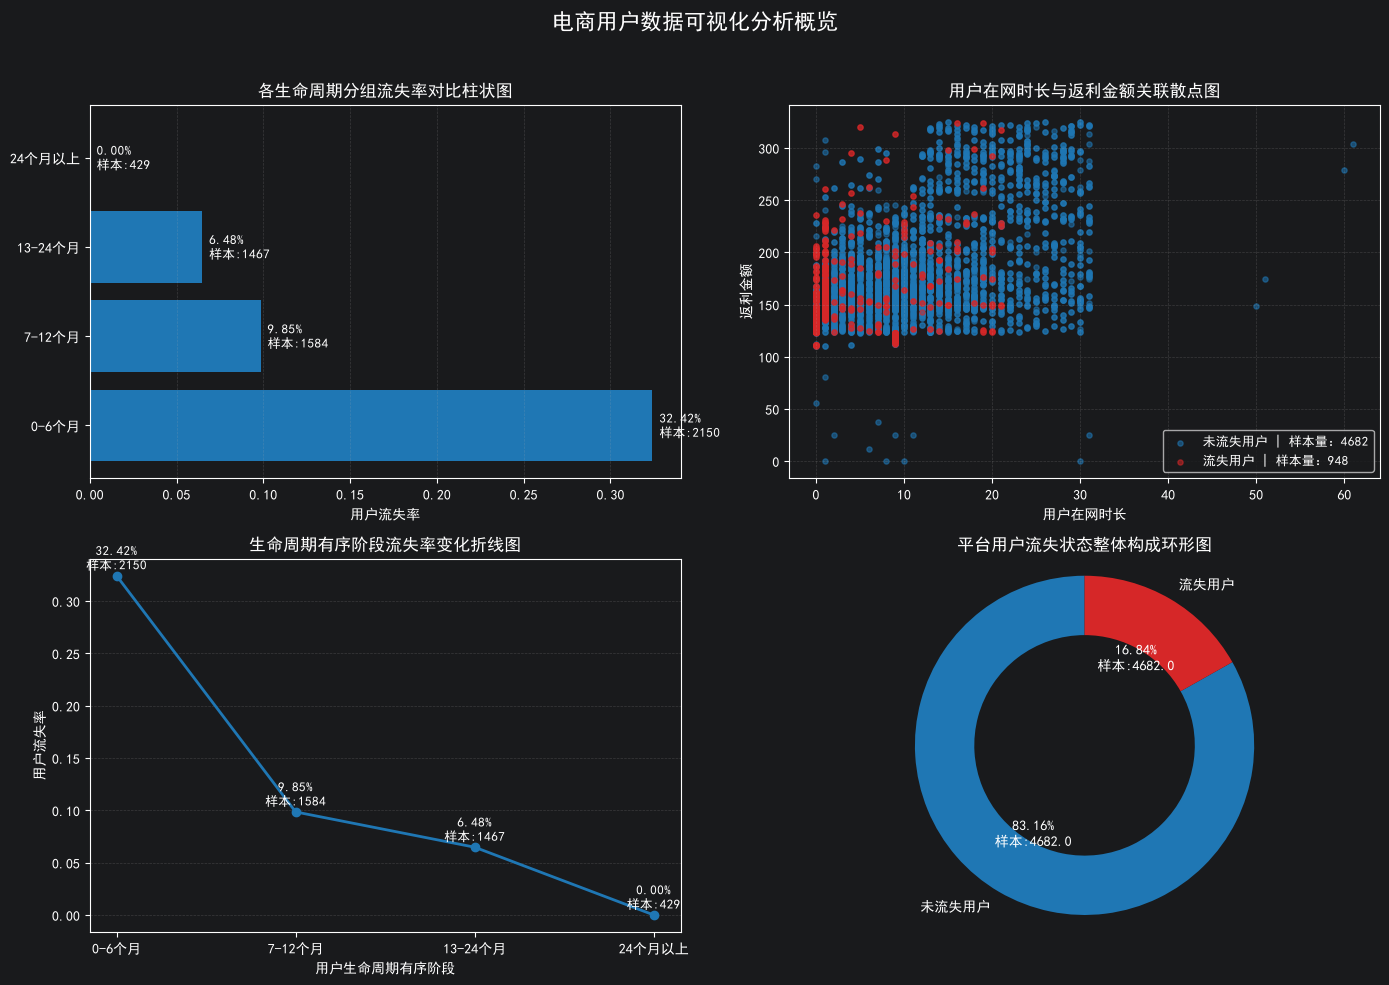

已输出： output\day06_visualization\day06_visualization_summary.png


In [46]:
## 任务5：2×2综合图
# 导入绘图库 + 全局中文与符号渲染配置
import matplotlib.pyplot as plt
plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

# 全局固定规范配色（全项目统一：未流失蓝、流失红）
COLOR_STAY = "#1f77b4"
COLOR_CHURN = "#d62728"

# 生命周期强制固定有序序列，和前面任务逻辑完全对齐
TENURE_ORDER = ["0-6个月", "7-12个月", "13-24个月", "24个月以上"]

# ---------------------- 基于原始数据集df聚合生成绘图所需数据（无外部文件依赖） ----------------------
# 柱状图、折线图共用分组统计数据
tenure_agg = df.groupby("TenureGroup", observed=True).agg(
    用户样本量=("CustomerID", "nunique"),
    流失总人数=("Churn", "sum")
).reindex(TENURE_ORDER).reset_index()
tenure_agg["流失率"] = tenure_agg["流失总人数"] / tenure_agg["用户样本量"]

# 散点图拆分流失/未流失两类用户明细
df_no_churn = df[df["Churn"] == 0].copy()
df_is_churn = df[df["Churn"] == 1].copy()
cnt_no_churn = df_no_churn.shape[0]
cnt_is_churn = df_is_churn.shape[0]
scatter_x_col = "Tenure"
scatter_y_col = "CashbackAmount"

# 环形构成图全局用户占比数据
churn_pie_agg = df.groupby("Churn", observed=True).agg(
    总用户数=("CustomerID", "nunique")
).reset_index()
churn_pie_agg["占比"] = churn_pie_agg["总用户数"] / churn_pie_agg["总用户数"].sum()
pie_text_labels = ["未流失用户", "流失用户"]
pie_color_palette = [COLOR_STAY, COLOR_CHURN]

# 题目指定画布初始化代码，完全原样保留
fig_summary, axes = plt.subplots(2, 2, figsize=(14, 10))

# TODO：分别在axes[0,0]、axes[0,1]、axes[1,0]、axes[1,1]绘制4张核心内容
ax_top_left, ax_top_right = axes[0]
ax_bottom_left, ax_bottom_right = axes[1]

# ========== 左上 axes[0,0] 任务1：生命周期流失率水平柱状图 ==========
bar_elements = ax_top_left.barh(tenure_agg["TenureGroup"], tenure_agg["流失率"], color=COLOR_STAY)
for idx, row_data in tenure_agg.iterrows():
    ax_top_left.text(
        x=row_data["流失率"] + 0.004,
        y=idx,
        s=f"{row_data['流失率']:.2%}\n样本:{row_data['用户样本量']}",
        va="center",
        fontsize=9
    )
ax_top_left.set_title("各生命周期分组流失率对比柱状图", fontsize=12)
ax_top_left.set_xlabel("用户流失率")
ax_top_left.grid(axis="x", alpha=0.22, linestyle="--")

# ========== 右上 axes[0,1] 任务2：在网时长&返利金额 散点图 ==========
ax_top_right.scatter(
    df_no_churn[scatter_x_col], df_no_churn[scatter_y_col],
    alpha=0.55, c=COLOR_STAY, s=14, label=f"未流失用户 | 样本量：{cnt_no_churn}"
)
ax_top_right.scatter(
    df_is_churn[scatter_x_col], df_is_churn[scatter_y_col],
    alpha=0.55, c=COLOR_CHURN, s=14, label=f"流失用户 | 样本量：{cnt_is_churn}"
)
ax_top_right.set_title("用户在网时长与返利金额关联散点图", fontsize=12)
ax_top_right.set_xlabel("用户在网时长")
ax_top_right.set_ylabel("返利金额")
ax_top_right.legend(fontsize=9)
ax_top_right.grid(alpha=0.22, linestyle="--")

# ========== 左下 axes[1,0] 任务3：生命周期有序阶段流失率折线图 ==========
ax_bottom_left.plot(
    tenure_agg["TenureGroup"], tenure_agg["流失率"],
    marker="o", linewidth=2, color=COLOR_STAY
)
for idx, row_data in tenure_agg.iterrows():
    ax_bottom_left.text(
        x=idx,
        y=row_data["流失率"] + 0.006,
        s=f"{row_data['流失率']:.2%}\n样本:{row_data['用户样本量']}",
        ha="center",
        fontsize=9
    )
ax_bottom_left.set_title("生命周期有序阶段流失率变化折线图", fontsize=12)
ax_bottom_left.set_xlabel("用户生命周期有序阶段")
ax_bottom_left.set_ylabel("用户流失率")
ax_bottom_left.grid(axis="y", alpha=0.22, linestyle="--")

# ========== 右下 axes[1,1] 任务4：用户流失整体构成环形图 ==========
ax_bottom_right.pie(
    x=churn_pie_agg["占比"],
    labels=pie_text_labels,
    autopct=lambda p: f"{p:.2f}%\n样本:{churn_pie_agg.iloc[int(p/100)]['总用户数']}",
    wedgeprops={"width": 0.35},
    colors=pie_color_palette,
    startangle=90
)
ax_bottom_right.set_title("平台用户流失状态整体构成环形图", fontsize=12)
ax_bottom_right.axis("equal")

# 原题固定总标题与全局留白控制，完全不修改
fig_summary.suptitle("电商用户数据可视化分析概览", fontsize=16)
fig_summary.tight_layout(rect=[0, 0, 1, 0.96])

# 输出路径沿用项目环境变量，兼容仓库目录结构
summary_path = OUTPUT_DIR / "day06_visualization_summary.png"
fig_summary.savefig(summary_path, dpi=150, bbox_inches="tight")
plt.show()

# 作业要求断言校验，原样保留
assert summary_path.exists() and summary_path.stat().st_size > 0, "综合图尚未保存"
print("已输出：", summary_path.relative_to(ROOT))


## 综合发现与局限

1. 综合发现1：内容：用户生命周期越长，流失概率持续降低，新注册前期是用户流失高发阶段。证据：0-6 个月用户流失率32.42%（样本2150），7-12个月流失率9.85%（样本 1584），13-24个月流失率6.48%（样本1467），24个月以上用户流失率降至 0%，柱状图与折线图均呈现清晰递减趋势。
2. 综合发现2：内容：平台整体用户留存基本面较好，仅小部分用户发生流失行为。证据：环形构成图显示未流失用户占比83.16%，样本量4682；流失用户仅占16.84%，样本量948，整体留存用户为绝对主体。
3. 综合发现3：内容：流失用户集中在在网时长较短、返现金额偏低区间；在网时间越久、返现额度越高的用户几乎不会流失。证据：右上散点图中，红色流失用户大量聚集在横轴左侧（在网时长短）、纵轴下方（返现金额低）区域；蓝色未流失用户覆盖更长在网时长与更高返现金额区间，两类人群分布边界明显。
4. 数据或方法局限：1.本数据集仅提供用户生命周期分组与静态快照数据，无真实时间序列流水，无法追踪单个用户随时间的动态行为，只能做横截面静态对比，不能推导严格因果关系；2. 仅使用返现金额作为行为指标，未引入订单金额、消费频次、投诉、会员等级等更多维度变量，分析维度较为单薄3. 生命周期分组为人工分段归类，分段区间具备主观性，不同分组方式可能得到略有差异的流失结论。

注意：`CashbackAmount`是返现金额，不是销售额、收入或GMV。


## 任务6：图表清单与检查点4

清单是第7天Flask读取图表说明的基础。每张图填写业务问题、图表类型、主要发现和局限。


In [47]:
# TODO：填写5行清单，不得保留“请填写”
chart_manifest = pd.DataFrame([
{
    "chart_id": "01",
    "file_name": "01_category_bar.png",
    "business_question": "不同用户生命周期分组的流失率差异对比",
    "chart_type": "bar",
    "key_finding": "用户入网初期0-6个月流失率最高达32.42%，随生命周期拉长流失率持续下降，24个月以上用户无流失",
    "limitation": "仅为横截面静态分组统计，无法追踪单用户长期动态流失路径，不能直接判定生命周期与流失存在因果关系"
},
{
    "chart_id": "02",
    "file_name": "02_behavior_scatter.png",
    "business_question": "用户在网时长与返现金额两个指标，如何区分流失与未流失人群",
    "chart_type": "scatter",
    "key_finding": "流失用户大多集中在在网时长短、返现金额偏低区域；未流失用户拥有更长在网时长与更高返现额度",
    "limitation": "返现金额不等于平台营收与GMV，仅能代表补贴力度，缺少消费订单数据支撑商业价值判断"
},
{
    "chart_id": "03",
    "file_name": "03_ordered_line.png",
    "business_question": "按生命周期有序阶段观察流失率连续变化趋势",
    "chart_type": "line",
    "key_finding": "从新用户到长期留存用户，流失率呈现单调递减趋势，用户使用越久留存稳定性越强",
    "limitation": "生命周期分段为人为设定区间，分段规则存在主观性，不同分段方式结果会产生小幅偏差"
},
{
    "chart_id": "04",
    "file_name": "04_composition_chart.png",
    "business_question": "整体用户大盘内流失与未流失用户的结构占比",
    "chart_type": "pie_or_bar",
    "key_finding": "整体未流失用户占比83.16%，流失用户仅占16.84%，平台整体用户留存基本面良好",
    "limitation": "仅展示全局静态构成，无法拆分各维度细分群体的流失结构，缺少多维度交叉分析"
},
{
    "chart_id": "05",
    "file_name": "day06_visualization_summary.png",
    "business_question": "电商用户流失多维度可视化整体概览",
    "chart_type": "dashboard",
    "key_finding": "四张子图从分组对比、行为关联、趋势变化、整体构成完整验证生命周期越久用户留存越好的核心结论",
    "limitation": "全部基于单份快照数据集分析，无时间序列多批次数据，结论泛化性有限"
},
])

assert len(chart_manifest) == 5
assert not chart_manifest.astype(str).apply(lambda col: col.str.contains("请填写").any()).any(), \
"请完成图表清单"

manifest_path = OUTPUT_DIR / "chart_manifest.csv"
chart_manifest.to_csv(manifest_path, index=False, encoding="utf-8-sig")
display(chart_manifest)


,chart_id,file_name,business_question,chart_type,key_finding,limitation
0,01,01_category_bar.png,不同用户生命周期分组的流失率差异对比,bar,用户入网初期0-6个月流失率最高达32.42%，随生命周期拉长流失率持续下降，24个月以上用...,仅为横截面静态分组统计，无法追踪单用户长期动态流失路径，不能直接判定生命周期与流失存在因果关系
1,02,02_behavior_scatter.png,用户在网时长与返现金额两个指标，如何区分流失与未流失人群,scatter,流失用户大多集中在在网时长短、返现金额偏低区域；未流失用户拥有更长在网时长与更高返现额度,返现金额不等于平台营收与GMV，仅能代表补贴力度，缺少消费订单数据支撑商业价值判断
2,03,03_ordered_line.png,按生命周期有序阶段观察流失率连续变化趋势,line,从新用户到长期留存用户，流失率呈现单调递减趋势，用户使用越久留存稳定性越强,生命周期分段为人为设定区间，分段规则存在主观性，不同分段方式结果会产生小幅偏差
3,04,04_composition_chart.png,整体用户大盘内流失与未流失用户的结构占比,pie_or_bar,整体未流失用户占比83.16%，流失用户仅占16.84%，平台整体用户留存基本面良好,仅展示全局静态构成，无法拆分各维度细分群体的流失结构，缺少多维度交叉分析
4,05,day06_visualization_summary.png,电商用户流失多维度可视化整体概览,dashboard,四张子图从分组对比、行为关联、趋势变化、整体构成完整验证生命周期越久用户留存越好的核心结论,全部基于单份快照数据集分析，无时间序列多批次数据，结论泛化性有限


In [48]:
required_outputs = [
    OUTPUT_DIR / "01_category_bar.png",
    OUTPUT_DIR / "02_behavior_scatter.png",
    OUTPUT_DIR / "03_ordered_line.png",
    OUTPUT_DIR / "04_composition_chart.png",
    OUTPUT_DIR / "day06_visualization_summary.png",
    OUTPUT_DIR / "chart_manifest.csv",
]
missing_outputs = [str(path.relative_to(ROOT)) for path in required_outputs if not path.exists()]
assert not missing_outputs, f"缺少成果文件：{missing_outputs}"

manifest_check = pd.read_csv(OUTPUT_DIR / "chart_manifest.csv")
assert list(manifest_check.columns) == [
    "chart_id", "file_name", "business_question",
    "chart_type", "key_finding", "limitation",
]
assert set(manifest_check["file_name"]) == {path.name for path in required_outputs[:-1]}

print("检查点4通过：第6天成果物完整")
print("下一步：重启内核并从头运行，然后执行提交检查脚本并推送GitHub。")


检查点4通过：第6天成果物完整
下一步：重启内核并从头运行，然后执行提交检查脚本并推送GitHub。
